<h1> Credit card fraud detection <h1>

The program is designed to study and analyse the credit card fraud. 

the information about the data is :

dataset containing legitimate and fraud transactions from the duration 1st Jan 2019 - 31st Dec 2020. It covers credit cards of 1000 customers doing transactions with a pool of 800 merchants.



In the taken data the column are respectively of the following categories : 
1. sn : symbol number 
2. trans date _ trans time : transaction date and transaction time 
3. cc_num : credit card number 
4. merchant : merchant name 
5. category: credit card category 
6. amt : amount 
7. first : first name of owner
8. last : last name of owner
9. gender : gender of owner
10. street : street address of the owner 
11. state : state address of the owner 
12. zip : zip address of the owner 
13. lat : latitude of the transaction
14. long : longitude of the transaction 
15. city_pop : population of the transaction city 
16. job : job of the owner
17. dob : date of birth of the owner
18. trans_num : transaction number 
19. unix_time : 
20. merch_lat : merchant latitude 
21. merch_long : merchant longitude 
22. is_fraud : is the transaction fraud


source : https://www.kaggle.com/datasets/kartik2112/fraud-detection

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.metrics import classification_report, confusion_matrix
from haversine import haversine
from datetime import datetime

<h1>Data Cleaning</h1>

In [2]:
def load_and_clean_data(filepath):
  df = pd.read_csv(filepath)
  numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
  df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())
  categorical_columns = df.select_dtypes(include=['object']).columns
  df[categorical_columns] = df[categorical_columns].fillna('Unknown')
  for col in df.columns:
    if df[col].dtype == 'object':
      try:
        df[col] = pd.to_datetime(df[col])
      except:
        pass
  df['is_fraud'] = df['is_fraud'].astype(bool)
  return df

def Encode(df):
  le = LabelEncoder()
  categorical_columns = df.select_dtypes(include=['object']).columns
  for col in categorical_columns:
    df[f'{col}_encoded'] = le.fit_transform(df[col])
  return df

if __name__ == "__main__":
  d = load_and_clean_data('fraudTest.csv')
  df = Encode(d)
  print("Data shape after processing:", df.shape)
  df.info()

C:\Users\rohan\AppData\Local\Temp\ipykernel_11072\1186684201.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col])
C:\Users\rohan\AppData\Local\Temp\ipykernel_11072\1186684201.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col])
C:\Users\rohan\AppData\Local\Temp\ipykernel_11072\1186684201.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col])
C:\Users\rohan\AppData\Local\Temp\ipykernel_11072\1186684201.py:10: UserWarning: Could not infer format, so each element will be parsed 

Data shape after processing: (555719, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 33 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Unnamed: 0             555719 non-null  int64         
 1   trans_date_trans_time  555719 non-null  datetime64[ns]
 2   cc_num                 555719 non-null  int64         
 3   merchant               555719 non-null  object        
 4   category               555719 non-null  object        
 5   amt                    555719 non-null  float64       
 6   first                  555719 non-null  object        
 7   last                   555719 non-null  object        
 8   gender                 555719 non-null  object        
 9   street                 555719 non-null  object        
 10  city                   555719 non-null  object        
 11  state                  555719 non-null  object        
 12  zi

<h1>EDA Tasks</h1>

**Basic EDA**

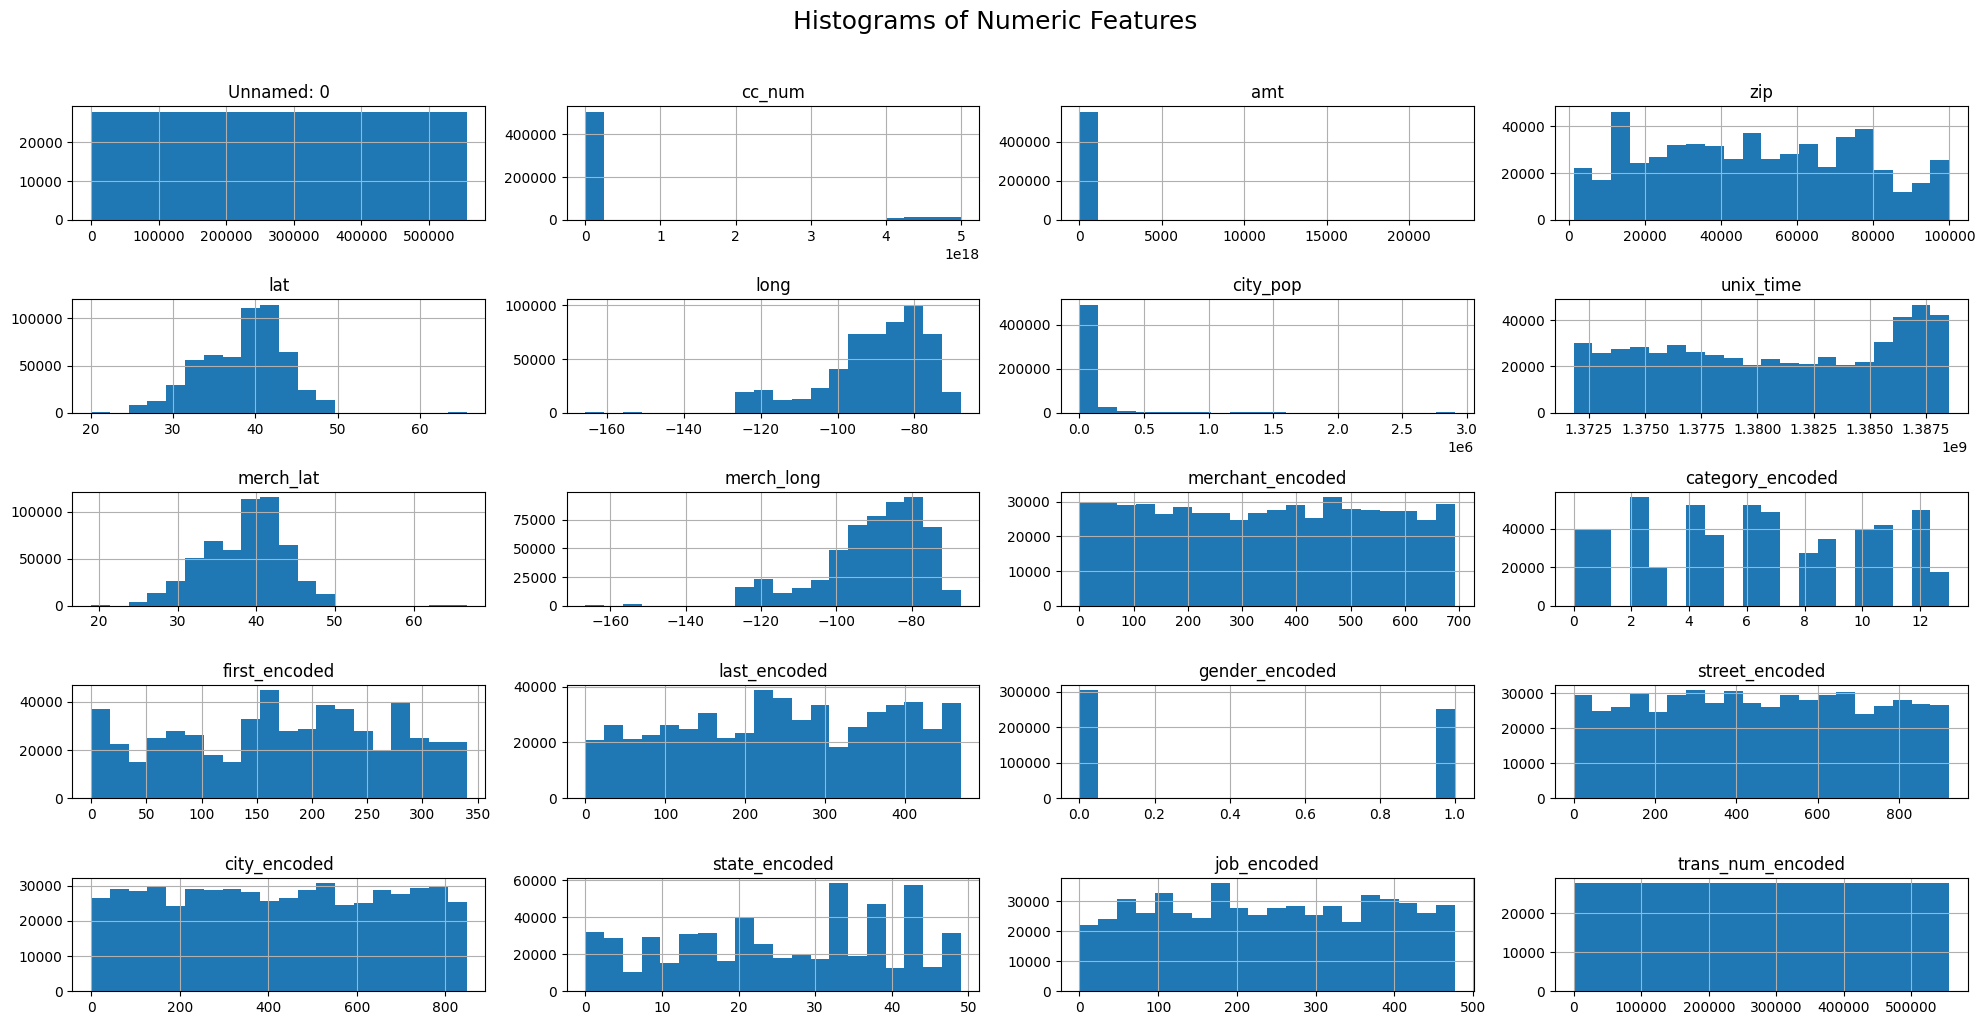

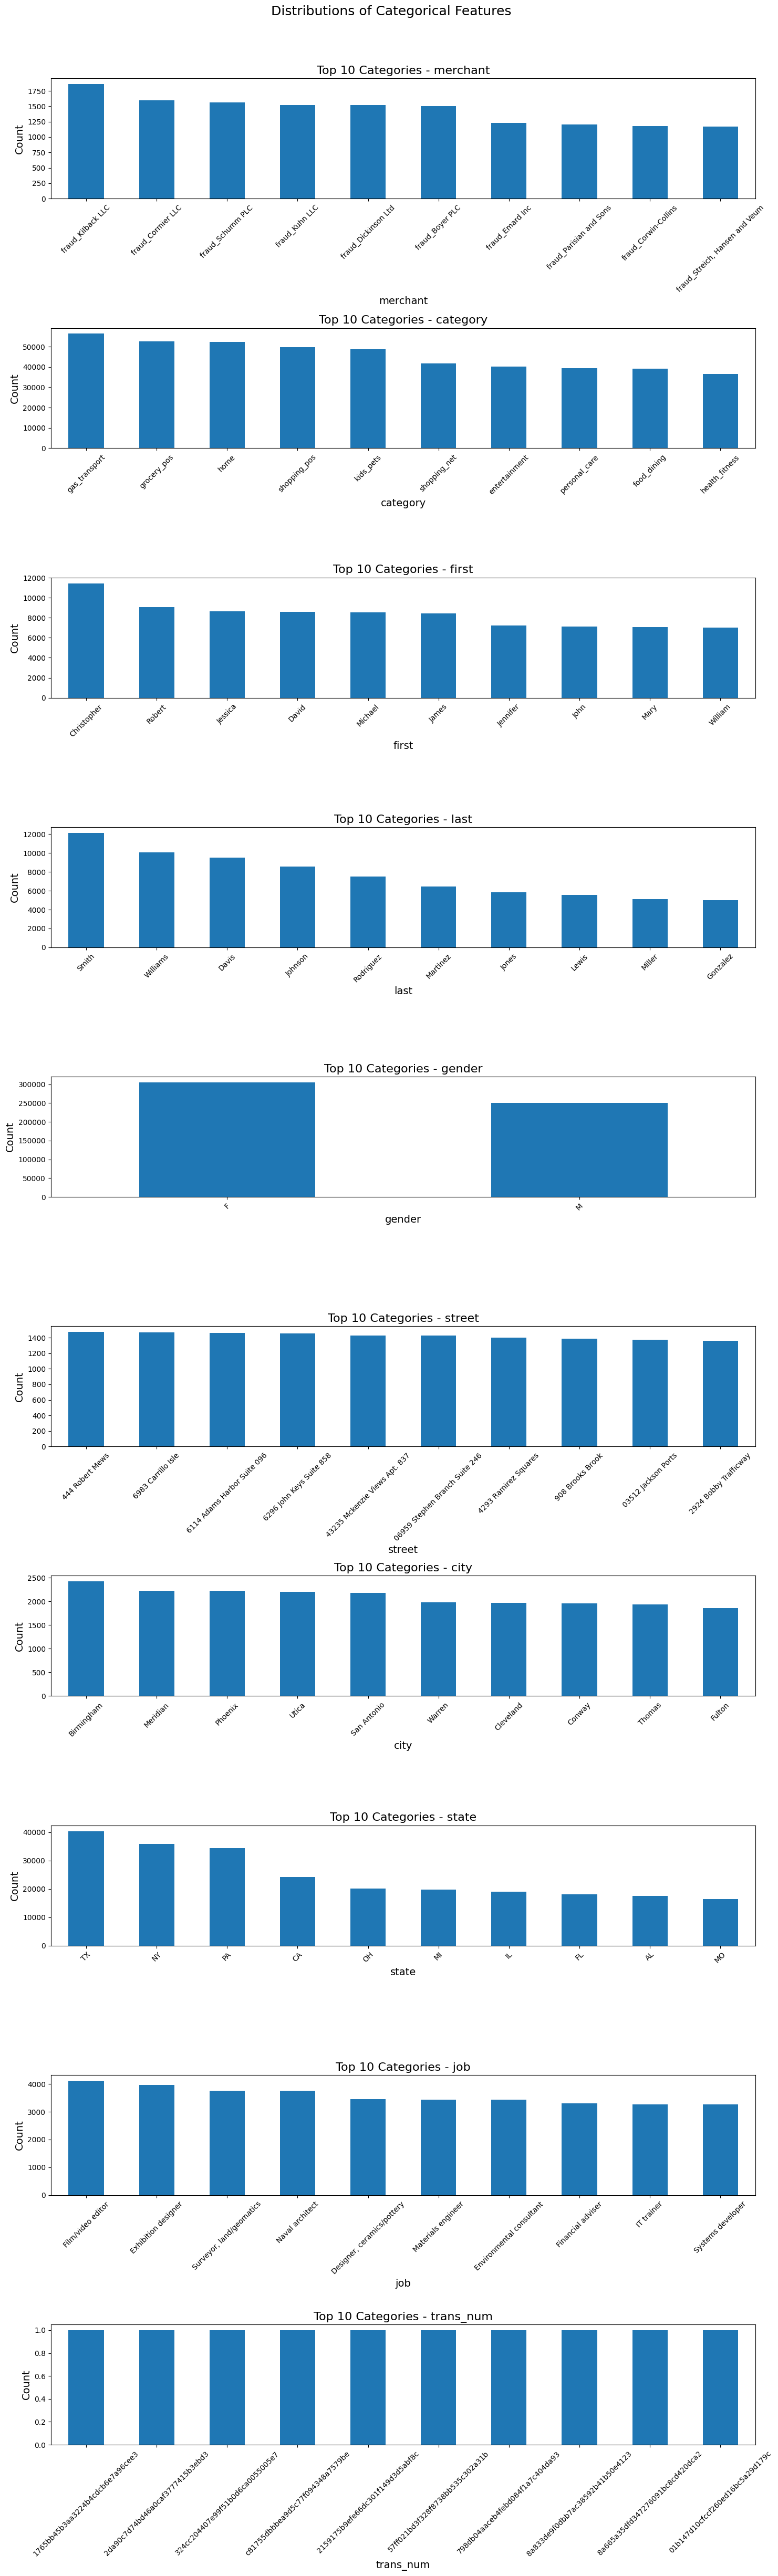

In [3]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_cols].hist(figsize=(20, 10), bins=20)
plt.suptitle('Histograms of Numeric Features', x=0.5, y=1.02, fontsize=18)
plt.tight_layout()
plt.show()

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
fig, axes = plt.subplots(nrows=len(categorical_cols), ncols=1, figsize=(15, 5*len(categorical_cols)))
fig.subplots_adjust(hspace=0.5)

N = 10  # Number of top categories to plot

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts().nlargest(N)  # Get top N categories
    ax = axes[i]
    counts.plot(kind='bar', ax=ax)
    ax.set_title(f'Top {N} Categories - {col}', fontsize=16)
    ax.set_xlabel(col, fontsize=14)
    ax.set_ylabel('Count', fontsize=14)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.suptitle('Distributions of Categorical Features', fontsize=18, y=0.98)
plt.show()

**Outlier Handling**


In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

for col in numeric_cols:
    df = remove_outliers_iqr(df, col)

print("Data shape after outlier handling:", df.shape)

Data shape after outlier handling: (373641, 33)


<h2>Assigned EDA</h2>

**1. Spatial & Geographic Analysis: Fraud Hotspots**
<ul>
    <li> Merchant vs. Transaction Location Anomalies</li>
    <ul>
        <li> Compute the distance between transaction location and merchant location
            (haversine(lat, long, merch_lat, merch_long)).</li>
        <li> Identify transactions where the cardholder is far from the merchant's
            location, which could indicate fraud.</li>
    </ul>
    <li> Fraud in High vs. Low Population Areas</li>
    <ul>
       <li> Compare fraud rates across different city_pop (urban vs. rural areas).</li>
        <li> Identify if fraud is more common in high or low-density areas.<li>
    </ul>
    <li> State-wise Fraud Trends<li>
    <ul>
        <li> Identify states where fraud rates are significantly higher than the average.</li>
    </ul>
</ul>

Transactions far from merchant's location: 18682
Fraud rates by city population: city_pop
23       0.001186
37       0.000000
46       0.000000
47       0.000000
49       0.000000
           ...   
36438    0.000000
36784    0.000000
38912    0.000000
45100    0.000000
45303    0.000000
Name: is_fraud, Length: 614, dtype: float64
States with higher than average fraud rates: state
CA    0.001100
CT    0.004134
IA    0.001161
ID    0.004684
IL    0.001280
IN    0.002058
KS    0.001364
MA    0.001901
MN    0.001793
MO    0.001114
MS    0.001254
MT    0.001687
NC    0.001670
NE    0.001623
NH    0.001286
NJ    0.001109
NM    0.002105
NY    0.001215
OK    0.002064
SC    0.001123
TN    0.001347
VA    0.001165
Name: is_fraud, dtype: float64


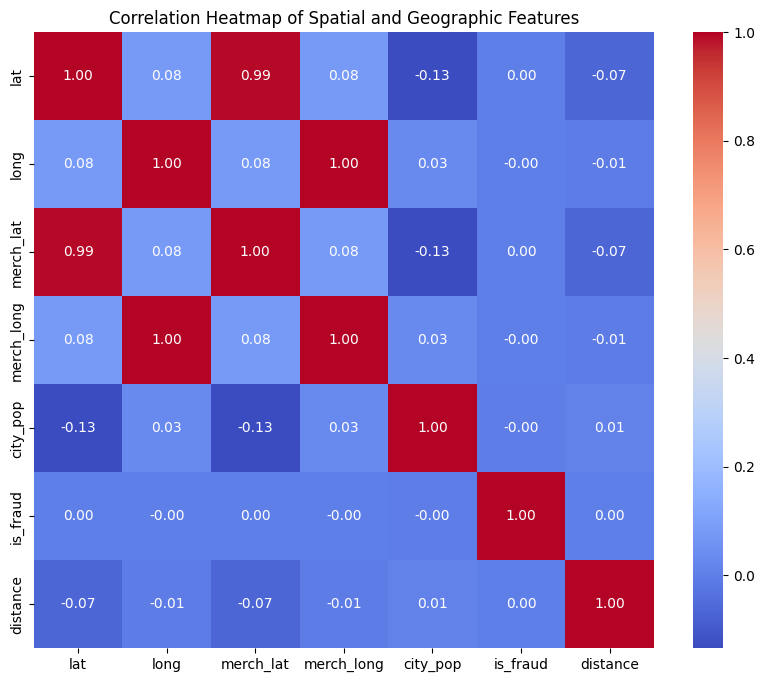

In [5]:
required_columns = ['lat', 'long', 'merch_lat', 'merch_long', 'city_pop', 'state', 'is_fraud']

if all(col in df.columns for col in required_columns):
    df['distance'] = df.apply(lambda row: haversine((row['lat'], row['long']), (row['merch_lat'], row['merch_long'])), axis=1)
    far_transactions = df[df['distance'] > df['distance'].quantile(0.95)]
    print("Transactions far from merchant's location:", far_transactions.shape[0])

    fraud_by_city_pop = df.groupby('city_pop')['is_fraud'].mean()
    print("Fraud rates by city population:", fraud_by_city_pop)

    fraud_by_state = df.groupby('state')['is_fraud'].mean()
    high_fraud_states = fraud_by_state[fraud_by_state > fraud_by_state.mean()]
    print("States with higher than average fraud rates:", high_fraud_states)
else:
    print("Error: Missing required columns in DataFrame.")
    missing_columns = [col for col in required_columns if col not in df.columns]
    print("Missing columns:", missing_columns)
    print("Dataframe shape:", df.shape)

spatial_cols = ['lat', 'long', 'merch_lat', 'merch_long', 'city_pop', 'is_fraud', 'distance']
spatial_df = df[spatial_cols]
corr = spatial_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Spatial and Geographic Features")
plt.show()

hence there is no correlation to the distance of transaction to wether the transaction is fraud T^T(fixed it yayyyy)


**2. Time-Based Fraud Patterns**
- Fraud During Unusual Hours
    - Extract hour and day of the week from unix_time.
    - Identify if fraud is more frequent during non-business hours (e.g., late at night) or weekends.

- Time Between Transactions (Velocity Features)
    - Compute time difference between consecutive transactions per user.
    - Identify users with many quick transactions in a short time (possible bot or stolen card activity).

- Recurring Transactions by the Same User
    - Identify if fraudulent transactions follow a recurring pattern (e.g., every X days, same merchant, same amount, etc.).

In [6]:
df['trans_time'] = pd.to_datetime(df['unix_time'], unit='s')
df['hour'] = df['trans_time'].dt.hour
df['day_of_week'] = df['trans_time'].dt.dayofweek

fraud_by_hour = df.groupby('hour')['is_fraud'].mean()
fraud_by_day_of_week = df.groupby('day_of_week')['is_fraud'].mean()

print("Fraud rates by hour:", fraud_by_hour)
print("Fraud rates by day of week:", fraud_by_day_of_week)

df['time_diff'] = df.groupby('cc_num')['unix_time'].diff()
quick_transactions = df[df['time_diff'] < df['time_diff'].quantile(0.05)]

print("Transactions with short time difference:", quick_transactions.shape[0])

recurring_transactions = df.groupby(['cc_num', 'merchant', 'amt'])['trans_num'].count()
recurring_transactions = recurring_transactions[recurring_transactions > 1]

print("Recurring transactions:", recurring_transactions.shape[0])

Fraud rates by hour: hour
0     0.002844
1     0.002711
2     0.002052
3     0.002781
4     0.000327
5     0.000248
6     0.000326
7     0.000327
8     0.000082
9     0.000164
10    0.000081
11    0.000325
12    0.000107
13    0.000106
14    0.000158
15    0.000212
16    0.000315
17    0.000158
18    0.000267
19    0.000373
20    0.000426
21    0.000212
22    0.005509
23    0.004858
Name: is_fraud, dtype: float64
Fraud rates by day of week: day_of_week
0    0.001037
1    0.001753
2    0.001610
3    0.001194
4    0.001183
5    0.000669
6    0.000543
Name: is_fraud, dtype: float64
Transactions with short time difference: 18638
Recurring transactions: 60


**3. Transaction Amount & Spending Behavior**
- High-Value vs. Low-Value Fraud
    - Analyze fraud rate by transaction amount (amt).
    - Identify common fraud amount thresholds (e.g., are fraudsters making small or large transactions?).
- Unusual Spending Patterns
    - Compute average spending per user and flag transactions that deviate significantly from a user’s normal spending behavior.
    - Detect cases where fraudsters try to avoid suspicion by mimicking previous spending habits.
- Category-Based Fraud Analysis
    - Analyze fraud rates by merchant category (category).
    - Identify which merchant categories are frequently targeted by fraudsters (e.g., luxury goods, online services, travel).

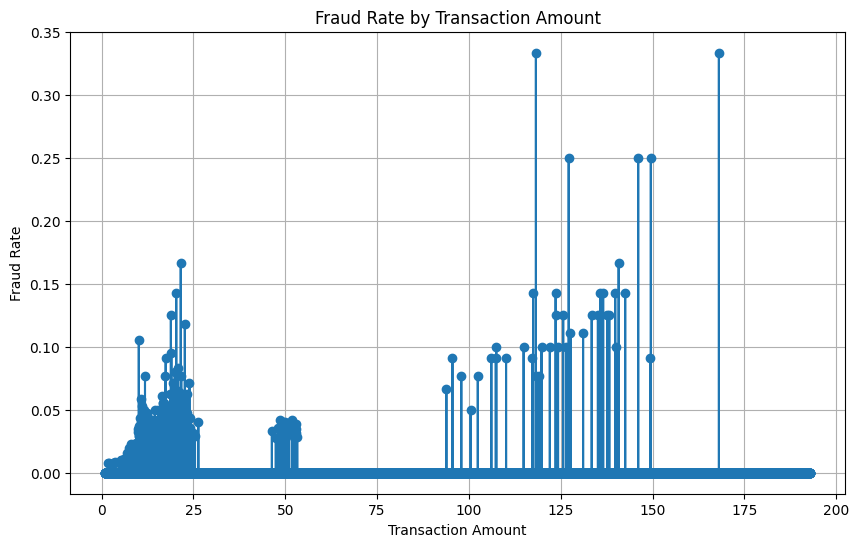

High-value transaction threshold: 136.36
Low-value transaction threshold: 2.37
Transactions with unusual spending patterns: 12724


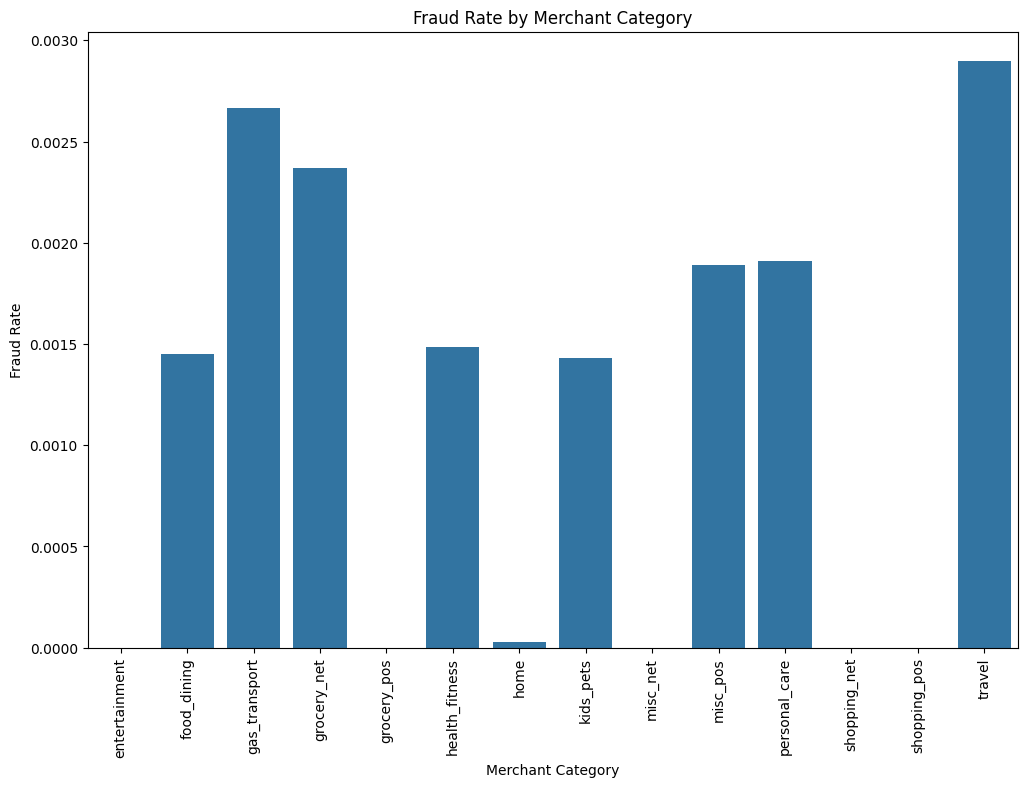

Merchant categories frequently targeted by fraudsters: ['food_dining', 'gas_transport', 'grocery_net', 'health_fitness', 'kids_pets', 'misc_pos', 'personal_care', 'travel']


In [7]:
fraud_by_amount = df.groupby('amt')['is_fraud'].mean()

plt.figure(figsize=(10, 6))
plt.plot(fraud_by_amount.index, fraud_by_amount.values, marker='o')
plt.title('Fraud Rate by Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Fraud Rate')
plt.grid(True)
plt.show()

high_value_threshold = df['amt'].quantile(0.95)
low_value_threshold = df['amt'].quantile(0.05)

print(f"High-value transaction threshold: {high_value_threshold}")
print(f"Low-value transaction threshold: {low_value_threshold}")

avg_spending_per_user = df.groupby('cc_num')['amt'].mean().reset_index()
avg_spending_per_user.rename(columns={'amt': 'amt_avg'}, inplace=True)

df = df.merge(avg_spending_per_user[['cc_num', 'amt_avg']], on='cc_num', how='left')

df['spending_deviation'] = np.abs(df['amt'] - df['amt_avg']) / df['amt_avg']

unusual_spending = df[df['spending_deviation'] > 2]  # Arbitrary threshold for significant deviation
print("Transactions with unusual spending patterns:", unusual_spending.shape[0])

fraud_by_category = df.groupby('category')['is_fraud'].mean()

plt.figure(figsize=(12, 8))
sns.barplot(x=fraud_by_category.index, y=fraud_by_category.values)
plt.title('Fraud Rate by Merchant Category')
plt.xlabel('Merchant Category')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=90)
plt.show()

high_fraud_categories = fraud_by_category[fraud_by_category > fraud_by_category.mean()]
print("Merchant categories frequently targeted by fraudsters:", high_fraud_categories.index.tolist())

**4. User Demographics & Fraud Susceptibility**
- Gender-Based Fraud Trends
    - Compare fraud rates between male and female cardholders.
    - Identify if certain genders are more targeted in fraud attempts.
- Age & Fraud Risk
    - Extract age from dob and analyze fraud rates across different age groups (e.g., <25, 25-40, 40-60, 60+).
    - Identify if fraudsters target specific age groups more often.
- Job Type & Fraud Patterns
    - Analyze fraud rates across different job titles (job).
    - Identify if certain professions are more or less prone to fraud.

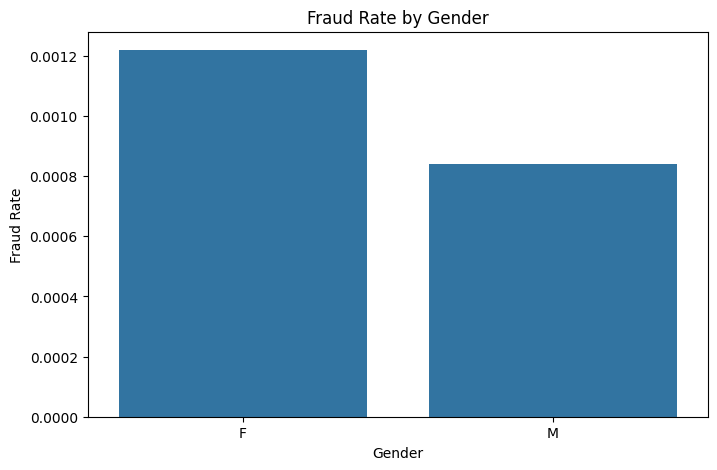

Fraud rates by gender: gender
F    0.001219
M    0.000840
Name: is_fraud, dtype: float64


C:\Users\rohan\AppData\Local\Temp\ipykernel_11072\2146336898.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_age_group = df.groupby('age_group')['is_fraud'].mean()


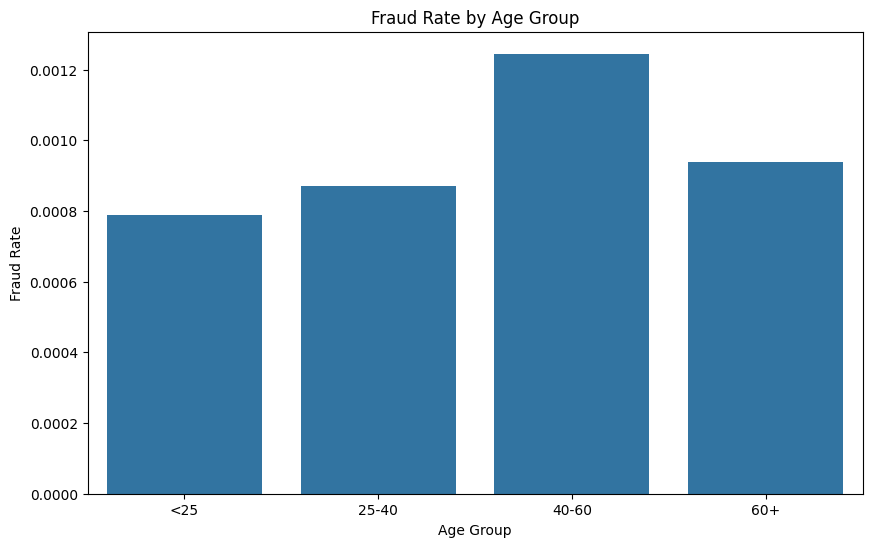

Fraud rates by age group: age_group
<25      0.000790
25-40    0.000872
40-60    0.001245
60+      0.000940
Name: is_fraud, dtype: float64


C:\Users\rohan\AppData\Local\Temp\ipykernel_11072\2146336898.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_jobs.index, y=top_jobs.values, palette='viridis')


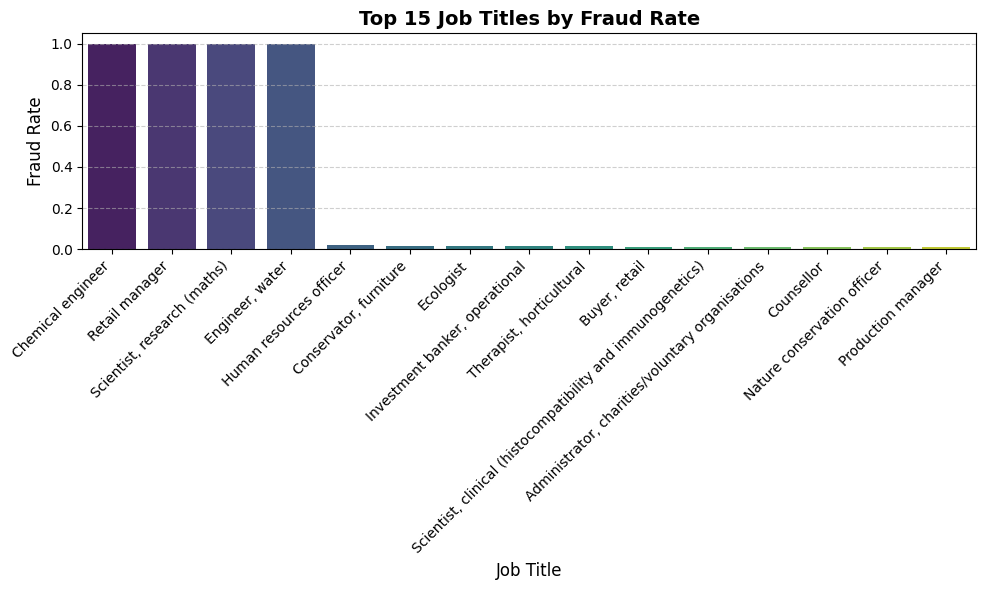

Top 15 job titles with the highest fraud rates:
job
Chemical engineer                                              1.000000
Retail manager                                                 1.000000
Scientist, research (maths)                                    1.000000
Engineer, water                                                1.000000
Human resources officer                                        0.021378
Conservator, furniture                                         0.015873
Ecologist                                                      0.014118
Investment banker, operational                                 0.014085
Therapist, horticultural                                       0.013636
Buyer, retail                                                  0.013100
Scientist, clinical (histocompatibility and immunogenetics)    0.012658
Administrator, charities/voluntary organisations               0.011864
Counsellor                                                     0.009524
Nature conse

In [8]:
fraud_by_gender = df.groupby('gender')['is_fraud'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=fraud_by_gender.index, y=fraud_by_gender.values)
plt.title('Fraud Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Fraud Rate')
plt.show()

print("Fraud rates by gender:", fraud_by_gender)

current_year = datetime.now().year
df['age'] = current_year - df['dob'].dt.year

age_bins = [0, 25, 40, 60, 100]
age_labels = ['<25', '25-40', '40-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

fraud_by_age_group = df.groupby('age_group')['is_fraud'].mean()

plt.figure(figsize=(10, 6))
sns.barplot(x=fraud_by_age_group.index, y=fraud_by_age_group.values)
plt.title('Fraud Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Fraud Rate')
plt.show()

print("Fraud rates by age group:", fraud_by_age_group)

fraud_by_job = df.groupby('job')['is_fraud'].mean().sort_values(ascending=False)
top_jobs = fraud_by_job.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_jobs.index, y=top_jobs.values, palette='viridis')
plt.title('Top 15 Job Titles by Fraud Rate', fontsize=14, weight='bold')
plt.xlabel('Job Title', fontsize=12)
plt.ylabel('Fraud Rate', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Top 15 job titles with the highest fraud rates:")
print(top_jobs)

**5. Location Consistency: Home vs. Transaction Region**
- User’s Home vs. Transaction Location
  - Compute distance between home location (lat, long) and transaction location (merch_lat, merch_long).
  - Identify transactions occurring far from the user’s home state or city (potential fraud signals).

- Cross-State or Cross-Country Transactions
  - Identify users making transactions in multiple states or countries within short time spans.
  - Compute the number of unique states a user transacts from and detect anomalies.

In [9]:
df['home_distance'] = df.apply(lambda row: haversine((row['lat'], row['long']), (row['merch_lat'], row['merch_long'])), axis=1)
far_home_transactions = df[df['home_distance'] > df['home_distance'].quantile(0.95)]
print("Transactions far from home location:", far_home_transactions.shape[0])

df['state_diff'] = df.groupby('cc_num')['state'].transform('nunique')
cross_state_transactions = df[df['state_diff'] > 1]
print("Users making transactions in multiple states:", cross_state_transactions['cc_num'].nunique())

Transactions far from home location: 18682
Users making transactions in multiple states: 0


**6. Feature Engineering for Model Enhancement**
- Transaction Count-Based Features
  - Compute the number of transactions per user in the last X days/hours.
  - Identify users making an abnormally high number of transactions in a short time window.
- Fraud Score Feature
  - Create a fraud risk score by combining:
    - Distance anomalies
    - Unusual spending behavior
    - Frequent small transactions
    - Transactions in high-fraud categories
    - Late-night transactions

In [10]:
df['transaction_count'] = df.groupby('cc_num')['trans_num'].transform('count')
high_transaction_users = df[df['transaction_count'] > df['transaction_count'].quantile(0.95)]
print("Users with abnormally high number of transactions:", high_transaction_users['cc_num'].nunique())

df['fraud_score'] = 0
df['fraud_score'] += (df['distance'] > df['distance'].quantile(0.95)) * 1
df['fraud_score'] += (df['spending_deviation'] > 2) * 1
df['fraud_score'] += (df['amt'] < df['amt'].quantile(0.05)) * 1
df['fraud_score'] += df['category'].isin(high_fraud_categories.index) * 1
df['fraud_score'] += ((df['hour'] > 22) | (df['hour'] < 6)) * 1

high_risk_transactions = df[df['fraud_score'] > 2]
print("High-risk transactions based on fraud score:", high_risk_transactions.shape[0])

Users with abnormally high number of transactions: 14
High-risk transactions based on fraud score: 4623


<h2>feature engineering</h2>

In [11]:
df['trans_time'] = pd.to_datetime(df['unix_time'], unit='s')
df = df.sort_values(by=['cc_num', 'trans_time'])

df['trans_24h'] = df.groupby('cc_num')['trans_time'].transform(
    lambda x: x.diff().dt.total_seconds().rolling(window=24*60*60, min_periods=1).count()
)

df['amt_24h_avg'] = df.groupby('cc_num')['amt'].transform(
    lambda x: x.rolling(window=24*60*60, min_periods=1).mean()
)

df['amt_24h_sum'] = df.groupby('cc_num')['amt'].transform(
    lambda x: x.rolling(window=24*60*60, min_periods=1).sum()
)

df['trans_7d'] = df.groupby('cc_num')['trans_time'].transform(
    lambda x: x.diff().dt.total_seconds().rolling(window=7*24*60*60, min_periods=1).count()
)

df['amt_7d_avg'] = df.groupby('cc_num')['amt'].transform(
    lambda x: x.rolling(window=7*24*60*60, min_periods=1).mean()
)

df['amt_7d_sum'] = df.groupby('cc_num')['amt'].transform(
    lambda x: x.rolling(window=7*24*60*60, min_periods=1).sum()
)

print(df.head())

      Unnamed: 0 trans_date_trans_time       cc_num                  merchant  \
102          157   2020-06-21 13:05:42  60416207185         fraud_Kutch-Ferry   
493          741   2020-06-21 16:25:36  60416207185     fraud_Halvorson Group   
2048        3047   2020-06-22 07:58:33  60416207185  fraud_Conroy-Cruickshank   
2918        4351   2020-06-22 15:32:31  60416207185          fraud_Larkin Ltd   
5176        7695   2020-06-23 12:28:54  60416207185     fraud_Leffler-Goldner   

           category     amt first  last gender            street  ...  \
102            home  124.66  Mary  Diaz      F  9886 Anita Drive  ...   
493        misc_pos   78.52  Mary  Diaz      F  9886 Anita Drive  ...   
2048  gas_transport   65.25  Mary  Diaz      F  9886 Anita Drive  ...   
2918      kids_pets   87.74  Mary  Diaz      F  9886 Anita Drive  ...   
5176  personal_care  148.02  Mary  Diaz      F  9886 Anita Drive  ...   

     home_distance state_diff  transaction_count  fraud_score  trans_24h  

<h1>feature reduction</h1>

**use of correlation**


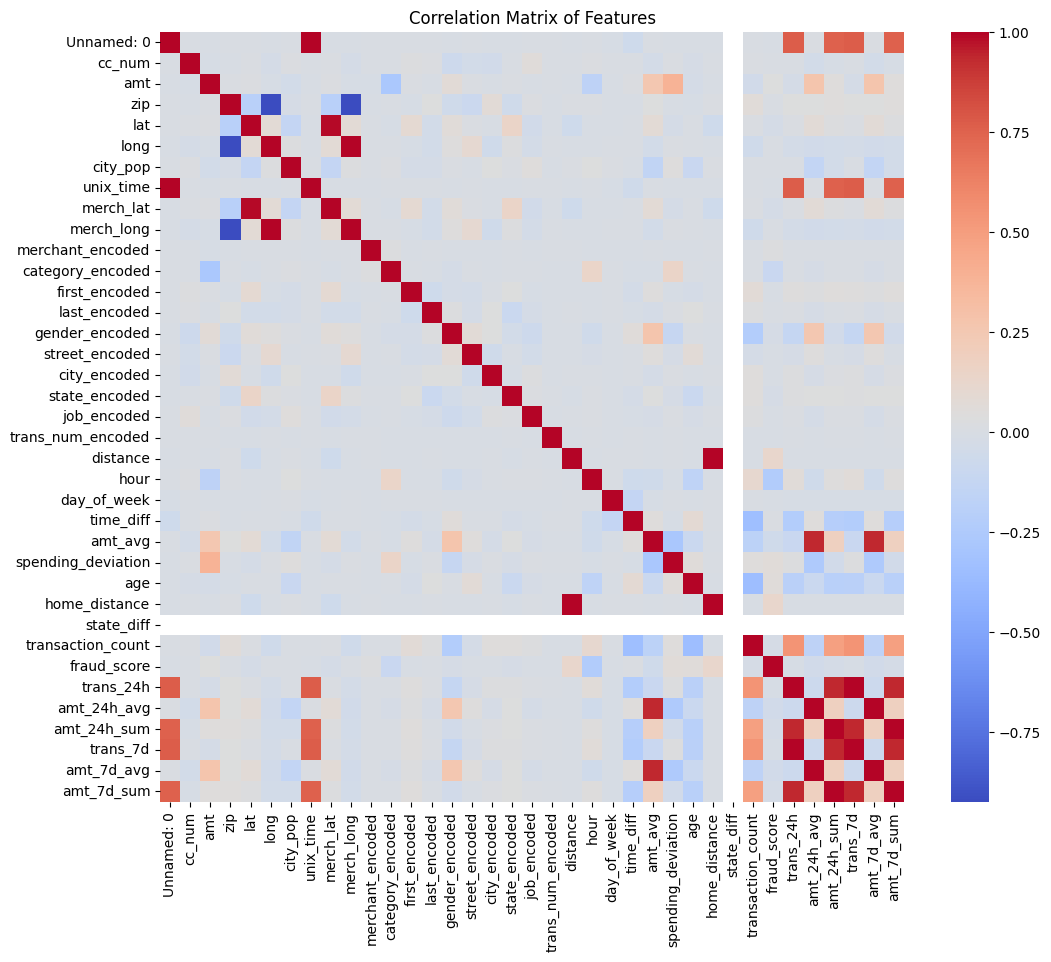

Remaining columns after feature reduction:
Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'is_fraud',
       'merchant_encoded', 'category_encoded', 'first_encoded', 'last_encoded',
       'gender_encoded', 'street_encoded', 'city_encoded', 'state_encoded',
       'job_encoded', 'trans_num_encoded', 'distance', 'trans_time', 'hour',
       'day_of_week', 'time_diff', 'amt_avg', 'spending_deviation', 'age',
       'age_group', 'state_diff', 'transaction_count', 'fraud_score',
       'trans_24h', 'amt_24h_avg', 'amt_24h_sum'],
      dtype='object')


In [12]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.show()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(abs(upper[column]) > 0.95)]
df = df.drop(columns=to_drop)

print("Remaining columns after feature reduction:")
print(df.columns)

**using PCA**


In [15]:
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

pca = PCA(n_components=0.95)
pca.fit(df[numeric_cols])
df_pca = pca.transform(df[numeric_cols])

print("Shape of data after PCA:", df_pca.shape)

Shape of data after PCA: (373641, 1)


**scaling**


In [16]:
from scipy.stats import skew
import pickle
import os
from sklearn.decomposition import PCA

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

skewness = df[numeric_cols].skew()
print("Normality test by analyzing skew before scaling or normalization")
print(skewness)

skewness_threshold = 1.0
highly_skewed_features = skewness[abs(skewness) > skewness_threshold].index.tolist()

for feature in highly_skewed_features:
    df[feature] = np.log1p(df[feature])

skewness_after_transformation = df[highly_skewed_features].skew()
print("\nSkewness after log1p transformation:")
print(skewness_after_transformation)

scaler = StandardScaler()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
skewness_before = df[numeric_cols].skew()

index = df.index
scaled_values = scaler.fit_transform(df[numeric_cols])
df_scaled = pd.DataFrame(scaled_values, index=index, columns=numeric_cols)
df[numeric_cols] = df_scaled

skewness_after = df[numeric_cols].skew()

scaler_filename = 'scaler_weights.pkl'
pickle.dump(scaler, open(scaler_filename, 'wb'))
print(f"\nScaler weights saved to {scaler_filename}")

print("\nSkewness before scaling or normalization")
print(skewness_before)
print("\nSkewness after scaling or normalization")
print(skewness_after)

Normality test by analyzing skew before scaling or normalization
Unnamed: 0            -0.002212
cc_num                 0.234489
amt                    0.839598
zip                    0.061521
lat                   -0.331990
long                  -0.643939
city_pop               2.702912
merchant_encoded       0.008258
category_encoded       0.077077
first_encoded         -0.187642
last_encoded          -0.077559
gender_encoded         0.178758
street_encoded         0.028497
city_encoded           0.087886
state_encoded         -0.259854
job_encoded           -0.009922
trans_num_encoded     -0.001030
distance              -0.233949
hour                  -0.278839
day_of_week           -0.404826
time_diff             25.480407
amt_avg                1.297265
spending_deviation     1.519855
age                    0.553298
state_diff             0.000000
transaction_count      0.082955
fraud_score            0.334620
trans_24h              0.832413
amt_24h_avg            1.133530
amt_24h

<h1>Model</h1>

In [20]:
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import joblib

print("\nTraining and Evaluating Models...")

X = df.drop(['is_fraud'], axis=1)
y = df['is_fraud']

numeric_cols = X.select_dtypes(include=[np.number]).columns
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns

imputer = SimpleImputer(strategy='mean')
X[numeric_cols] = imputer.fit_transform(X[numeric_cols])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nOriginal class distribution:")
print(Counter(y_train))

smote = SMOTE(random_state=42)
X_train_numeric = X_train[numeric_cols]
X_test_numeric = X_test[numeric_cols]

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_numeric, y_train)

print("\nClass distribution after SMOTE:")
print(Counter(y_train_balanced))

models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000),
    "MLPClassifier": MLPClassifier(random_state=42, max_iter=500)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name} model...")
    model.fit(X_train_balanced, y_train_balanced)

    print("\nMaking predictions...")
    y_pred = model.predict(X_test_numeric)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {accuracy:.2%}")
    print(f"\n{name} F1 Score: {f1:.2f}")
    print(f"\n{name} R2 Score: {r2:.2f}")

    results[name] = accuracy

print("\nModel Comparison:")
for name, accuracy in results.items():
    print(f"{name}: {accuracy:.2%}")

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print(f"\nBest Model: {best_model_name} with Accuracy: {results[best_model_name]:.2%}")


joblib.dump(best_model, 'fraud_detection_model.pkl')
print("Model saved")


Training and Evaluating Models...

Original class distribution:
Counter({False: 298593, True: 319})

Class distribution after SMOTE:
Counter({False: 298593, True: 298593})

Training RandomForest model...

Making predictions...

RandomForest Accuracy: 99.92%

RandomForest F1 Score: 0.37

RandomForest R2 Score: 0.14

Training LogisticRegression model...

Making predictions...

LogisticRegression Accuracy: 82.35%

LogisticRegression F1 Score: 0.01

LogisticRegression R2 Score: -182.36

Training MLPClassifier model...

Making predictions...

MLPClassifier Accuracy: 99.85%

MLPClassifier F1 Score: 0.30

MLPClassifier R2 Score: -0.58

Model Comparison:
RandomForest: 99.92%
LogisticRegression: 82.35%
MLPClassifier: 99.85%

Best Model: RandomForest with Accuracy: 99.92%
Model saved
